## <center>Enhancing Customer Churn Prediction: A Hybrid Stacking Model Using Random Forest and XGBoost</center>

**Stacking** is an ensemble learning technique that **combines multiple machine learning models to improve prediction accuracy**. Instead of relying on a single model, stacking trains base models separately, then feeds their predictions as inputs to a meta-model **(Logistic Regression)**. The meta-model learns how to best combine the base models' outputs, leveraging their strengths while minimizing weaknesses. **Random Forest** is robust against overfitting and handles categorical data well, while **XGBoost** is highly efficient and excels in capturing complex patterns. **By stacking them, we leverage their strengths and compensate for individual weaknesses, creating a more accurate and generalizable model.**

### Data Pre-processing

#### Importing Libraries

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

#### Loading the Dataset

In [3]:
# Load Data
dataset = pd.read_csv("Churn_Modelling.csv")

In [4]:
dataset

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


#### Dropping Unnecessary Columns

In [5]:
# Drop unnecessary columns
dataset = dataset.drop(columns=["RowNumber", "Surname"])

In [6]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding
dataset["Geography"] = label_encoder.fit_transform(dataset["Geography"])
dataset["Gender"] = label_encoder.fit_transform(dataset["Gender"])

### Feature Engineering

Categorizing age into groups is based on the premise that **age-related behavior tends to follow patterns rather than individual differences**. Customers within a certain age range often exhibit similar financial habits, risk tolerance, and churn likelihood. **By grouping ages into five distinct categories, the model can generalize better and reduce unnecessary complexity**. This is particularly beneficial for tree-based models like Random Forest, which handle categorical variables efficiently and may struggle with small numerical variations that do not contribute meaningfully to classification.

Similarly, the balance-to-salary ratio introduces a more interpretable financial metric than raw balance or salary alone. **Two customers with the same balance but vastly different salaries may have different financial stability**, which could influence their likelihood of churning. **By normalizing balance relative to salary, we provide the model with a scaled and more comparable feature across all customers**. This prevents high-salary customers from skewing the balance feature’s importance and ensures that the model focuses on financial proportionality rather than absolute amounts.

#### Creating Age Group and Balance-to-Salary Ratio Features

In [7]:
# Create Age Group Feature
dataset["AgeGroup"] = pd.cut(dataset["Age"], bins=[18, 30, 40, 50, 60, 100], labels=[0, 1, 2, 3, 4], include_lowest=True)

# Balance-to-Salary Ratio Feature
dataset["BalanceSalaryRatio"] = dataset["Balance"] / (dataset["EstimatedSalary"] + 1)  # Avoid division by zero

# Handle Infinite Values
dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
dataset.dropna(inplace=True)

In [34]:
# Verify the mapping of ages to age groups
age_mapping = dataset.groupby("AgeGroup")["Age"].unique()
age_mapping_dict = {group: list(ages) for group, ages in age_mapping.items()}

# Print the mapped values
for group, ages in age_mapping_dict.items():
    print(f"Age Group {group}: {ages}")

Age Group 0: [29, 28, 30, 25, 21, 26, 24, 22, 19, 27, 23, 20, 18]
Age Group 1: [37, 35, 40, 38, 39, 36, 34, 31, 32, 33]
Age Group 2: [49, 50, 46, 47, 48, 43, 42, 44, 41, 45]
Age Group 3: [54, 57, 52, 58, 55, 51, 56, 53, 60, 59]
Age Group 4: [61, 62, 64, 65, 63, 69, 66, 70, 71, 68, 84, 72, 67, 73, 74, 76, 77, 75, 81, 83, 79, 92, 78, 80, 88, 82, 85]


> #### Age Group Categories Guide:
> - **Age Group 0 (18-30):** Young Adults
> - **Age Group 1 (31-40):** Early Middle-Age
> - **Age Group 2 (41-50):** Mid-Life Adults
> - **Age Group 3 (51-60):** Pre-Retirement
> - **Age Group 4 (61-92):** Retirees & Seniors

> #### Balance-to-Salary Ratio (BSR) Guide:
> - **Low BSR (≤ 0.1)**: High churn risk (Customer may be financially unstable or less engaged).
> - **Moderate BSR (0.1 - 1.0)**:Churn depends on engagement & product offerings.
> - **High BSR (> 1.0)**: Low churn risk (Customer relies on the bank for savings).

In [8]:
# Define Features and Target Variable
X = dataset.drop(columns=["Exited"])  # Features
y = dataset["Exited"]  # Target (churn)

In [9]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Stacking Ensemble Machine Learning

### Model 1: Random Forest

**Random Forest** is an machine learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. Its strength lies in its <i>robustness to overfitting, ability to handle large datasets, feature importance insights, and resilience to noisy data and outliers.</i>

In [10]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)
rf_train_preds = rf_model.predict_proba(X_train)[:, 1]  # Probability estimates

### Model 2: XGBoost

**XGBoost** (Extreme Gradient Boosting) is a machine learning algorithm that uses gradient boosting to optimize predictive performance. Its strength lies in its <i>high accuracy, speed, and ability to handle missing values and complex patterns while preventing overfitting through regularization.</i>

In [11]:
# XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    random_state=42, 
    use_label_encoder=False, 
    eval_metric="logloss", 
    enable_categorical=False
)
xgb_model.fit(X_train.astype(float), y_train)
xgb_train_preds = xgb_model.predict_proba(X_train.astype(float))[:, 1]

C:\ANACONDA\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:53:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [12]:
# Stack base model predictions as new features
X_train_meta = np.column_stack((rf_train_preds, xgb_train_preds))
X_test_meta = np.column_stack((
    rf_model.predict_proba(X_test)[:, 1],
    xgb_model.predict_proba(X_test.astype(float))[:, 1]
))

### Logistic Regression Meta-Model

In [13]:
# Train Logistic Regression as Meta-Model
meta_model = LogisticRegression()
meta_model.fit(X_train_meta, y_train)

LogisticRegression()

In [14]:
# Cross-Validation Accuracy
cv_scores = cross_val_score(meta_model, X_train_meta, y_train, cv=5, scoring="accuracy")
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Validation Accuracy: 0.9507 ± 0.0050


In [15]:
# Stacked Model Accuracy
stacked_preds = meta_model.predict(X_test_meta)
stacked_accuracy = accuracy_score(y_test, stacked_preds)
print(f"Stacked Model Accuracy: {stacked_accuracy:.4f}")

Stacked Model Accuracy: 0.8580


> The **cross-validation accuracy (95.07%)** shows that the model performed well during training, and the **stacked model accuracy (85.80%)** on the test set is still strong. While there is some drop in accuracy, it is not drastic, meaning the model generalizes well overall. The high test accuracy confirms that stacking leveraged the strengths of both Random Forest and XGBoost, though further fine-tuning could enhance generalization even more.

In [16]:
# Classification Report for Stacked Model
print("Classification Report for Stacked Model:")
print(classification_report(y_test, stacked_preds))

Classification Report for Stacked Model:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1607
           1       0.66      0.56      0.61       393

    accuracy                           0.86      2000
   macro avg       0.78      0.75      0.76      2000
weighted avg       0.85      0.86      0.85      2000



> The stacked model performs well in predicting **customer retention** but is less confident in identifying those who will churn. This means it is **effective in most cases but may occasionally miss some customers who are likely to leave**. Overall, the model provides useful insights for predicting churn, and its performance is strong for a straightforward prediction approach.

In [17]:
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, stacked_preds))

Confusion Matrix:
[[1494  113]
 [ 171  222]]


In [18]:
# Ensure dataset is assigned the final processed data
dataset = dataset.copy()

# Drop the target column (Exited) from dataset to get features for prediction
X_full = dataset.drop(columns=["Exited"], errors="ignore")

# Get predictions from base models (Random Forest & XGBoost)
rf_probs = rf_model.predict_proba(X_full)[:, 1]
xgb_probs = xgb_model.predict_proba(X_full)[:, 1]

# Create stacked features (Meta-Model Inputs)
X_meta_full = pd.DataFrame({"RF": rf_probs, "XGB": xgb_probs})

# Predict churn probability using the trained meta-model
dataset["Churn_Probability"] = meta_model.predict_proba(X_meta_full)[:, 1]

# Define mappings for categorical variables
gender_mapping = {0: "Female", 1: "Male"}
geography_mapping = {0: "France", 1: "Germany", 2: "Spain"}
binary_mapping = {0: "No", 1: "Yes"}  # For HasCrCard and IsActiveMember

# Apply mappings
if "Gender" in dataset.columns:
    dataset["Gender"] = dataset["Gender"].map(gender_mapping)

if "Geography" in dataset.columns:
    dataset["Geography"] = dataset["Geography"].map(geography_mapping)

if "HasCrCard" in dataset.columns:
    dataset["HasCrCard"] = dataset["HasCrCard"].map(binary_mapping)

if "IsActiveMember" in dataset.columns:
    dataset["IsActiveMember"] = dataset["IsActiveMember"].map(binary_mapping)

# Sort dataset by churn probability in descending order
dataset = dataset.sort_values(by="Churn_Probability", ascending=False)

# Display the first 10 customers with the highest churn probability
print(dataset)

      CustomerId  CreditScore Geography  Gender  Age  Tenure    Balance  \
6911    15710087          705   Germany  Female   54       3  125889.30   
4013    15653776          720   Germany  Female   57       1  162082.31   
1657    15752342          704   Germany  Female   54       6  133656.91   
1962    15692416          358     Spain  Female   52       8  143542.36   
2614    15640846          546   Germany  Female   58       3  106458.31   
...          ...          ...       ...     ...  ...     ...        ...   
9118    15804052          710     Spain    Male   23       6       0.00   
9080    15620443          711    France  Female   81       6       0.00   
7720    15700693          693    France    Male   68       2       0.00   
310     15712287          652    France  Female   80       4       0.00   
7526    15800554          850    France  Female   81       1       0.00   

      NumOfProducts HasCrCard IsActiveMember  EstimatedSalary  Exited  \
6911              3       

C:\ANACONDA\Lib\site-packages\sklearn\base.py:457: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---

## Feature Importance

#### Random Forest

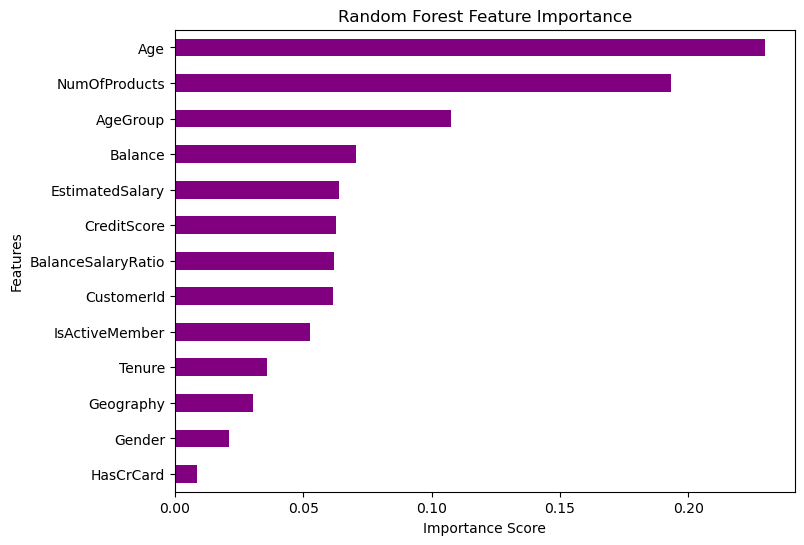

In [28]:
# Feature Importance for Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_importance.sort_values(ascending=True).plot(kind="barh", title="Random Forest Feature Importance", figsize=(8, 6), color="purple")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

> The Random Forest feature importance highlights Age, NumOfProducts, and AgeGroup as the most influential features in predicting customer churn. **Age** is the most significant factor, suggesting that customer retention varies by age. **NumOfProducts** follows closely, indicating that the number of products a customer holds strongly impacts their likelihood of leaving. **AgeGroup** ranks third, reinforcing that age-based segmentation plays a key role in churn prediction.

#### XGBoost

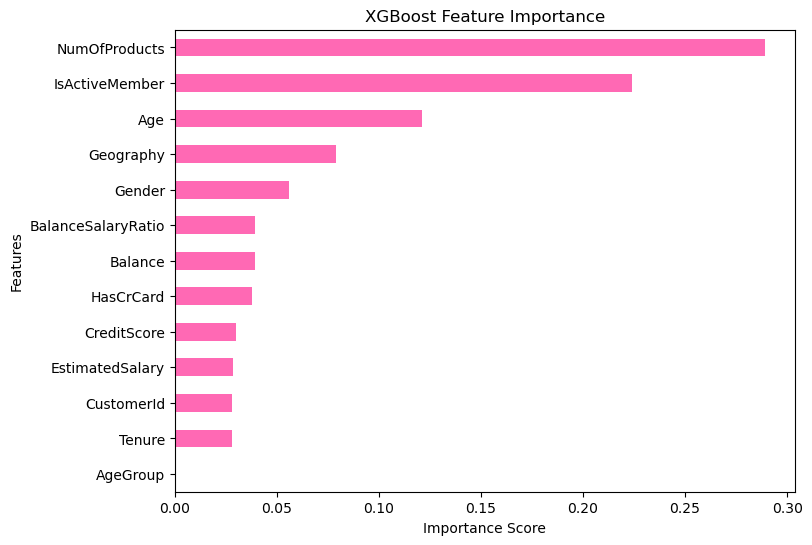

In [33]:
# Feature Importance for XGBoost
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
xgb_importance.sort_values(ascending=True).plot(kind="barh", title="XGBoost Feature Importance", figsize=(8, 6), color="hotpink")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

> The XGBoost feature importance results highlight **NumOfProducts**, **IsActiveMember**, and **Age** as the top predictors of customer churn. Notably, **AgeGroup** is missing, likely because XGBoost found the raw Age feature more informative. Since AgeGroup is a categorized version, the model likely ignored it in favor of the more precise numerical data.

#### Feature Importance for Both Models

Random Forest and XGBoost determine feature importance differently. Random Forest calculates importance based on how much a feature reduces impurity across all decision trees. It tends to spread importance across correlated features, which is why both Age and AgeGroup received rankings. On the other hand, XGBoost uses boosting and assigns importance based on how much a feature improves model performance, often dropping redundant features. In this case, XGBoost ranked Age highly but ignored AgeGroup, likely because Age provided enough information, making AgeGroup unnecessary. This highlights how Random Forest retains more correlated features, while XGBoost is more selective in feature ranking.

---

## Rank Averaging for Feature Importance Aggregation

To create a balanced final ranking where the importance rankings from both models are averaged, this simple yet effective ensemble feature selection technique helps mitigate differences in how models calculate importance and ensures that no single model disproportionately influences feature selection.

This process extracts **feature importance scores** from both **Random Forest** and **XGBoost**, merges them, and calculates the average importance for each feature. It then sorts the features based on their average importance scores, ensuring a balanced evaluation from both models. 

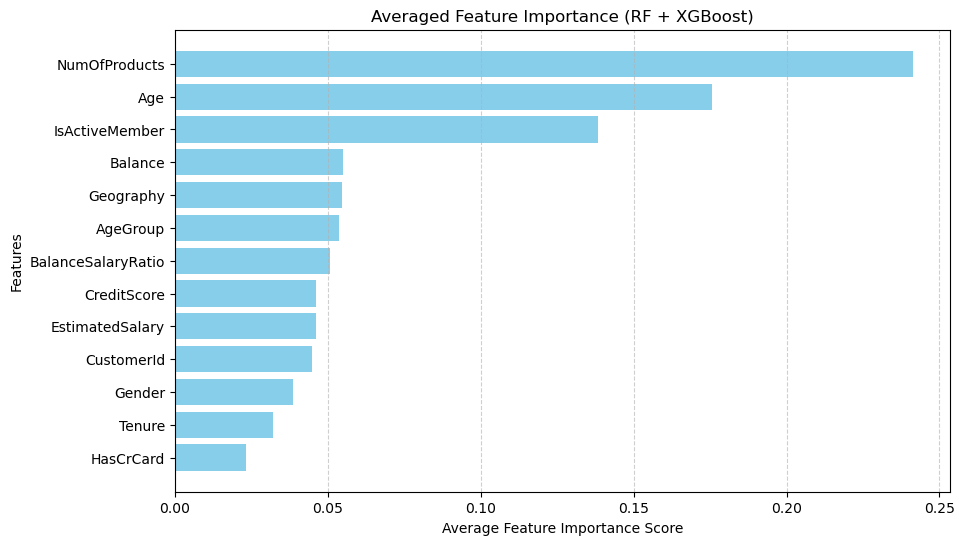

               Feature  Avg_Importance
7        NumOfProducts        0.241296
4                  Age        0.175541
9       IsActiveMember        0.138254
6              Balance        0.054912
2            Geography        0.054723
11            AgeGroup        0.053684
12  BalanceSalaryRatio        0.050718
1          CreditScore        0.046270
10     EstimatedSalary        0.046106
0           CustomerId        0.044791
3               Gender        0.038524
5               Tenure        0.031977
8            HasCrCard        0.023204


In [27]:
# Get feature importance from trained Random Forest model
rf_importance = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({'Feature': X.columns, 'RF_Importance': rf_importance})

# Get feature importance from trained XGBoost model
xgb_importance = xgb_model.feature_importances_
xgb_importance_df = pd.DataFrame({'Feature': X.columns, 'XGB_Importance': xgb_importance})

# Merge both feature importance scores
importance_df = rf_importance_df.merge(xgb_importance_df, on="Feature")

# Compute the average importance score instead of rank
importance_df["Avg_Importance"] = (importance_df["RF_Importance"] + importance_df["XGB_Importance"]) / 2

# Sort by average importance (higher importance = higher value)
importance_df = importance_df.sort_values(by="Avg_Importance", ascending=True)

# Plot the improved bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Avg_Importance"], color="skyblue")
plt.xlabel("Average Feature Importance Score")
plt.ylabel("Features")
plt.title("Averaged Feature Importance (RF + XGBoost)")
plt.grid(axis="x", linestyle="--", alpha=0.6)  # Add grid for better readability
plt.show()

# Print the final combined feature importance scores in descending order
print(importance_df[['Feature', 'Avg_Importance']].sort_values(by="Avg_Importance", ascending=False))

> The averaged feature importance shows that **NumOfProducts** is the most influential factor, followed by **Age** and **IsActiveMember**, indicating that customer engagement and product holdings strongly impact predictions. **Balance**, **Geography**, and **AgeGroup** have moderate effects, while **HasCrCard**, **Tenure**, and **Gender** contribute minimally, suggesting they have little influence.